In [1]:
from pathlib import Path 

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scienceplots
import numpy as np

plt.style.use(['ieee', 'nature'])

%matplotlib inline

In [2]:
dir = Path('./data/')
dir

PosixPath('data')

In [3]:
lnareviewdf = pd.read_csv(dir/'us_lna_survey.csv')

lnareviewdf

,Group,Work,Technology,Transducer Type,Supply(V),Lmin,Pitch(µm),LNA Architecture,Pitch Matched,Transducer Capacitance (pF),...,-3dB BW (MHz),IRNC @ F0 (pA/\sqrt{Hz}),IRNV @ F0 (nV/\sqrt{Hz}),IRNA @ F0 (mPa/\sqrt{Hz}),PSRR @ F0(dBc),Peak SNR@BW(dB),Power Dissipation(mW),Area (mm^2),DOI,Notes
0,EI-TUDelft,PGuoJSSC2022,180nm CMOS-BCD,PZT,1.8,180nm,100,CL-CA,Yes,1.0,...,17.5,1.31,NR,NR,26,48.0,0.8000,0.025,https://doi.org/10.1109/JSSC.2022.3200160,NaN
1,EI-TUDelft,MTanJSSC2018,180nm HVCMOS,PZT,1.9,180nm,100,TIA,No,0.7,...,16.0,2.00,NR,NR,16,42.0,0.7900,0.027,https://doi.org/10.1109/JSSC.2018.2828826,Originally observed effect of PSRR in inter-ch...
2,MEDR/CICS-MIT/ButterflyIQ,KChenJSSC2015,180nm CMOS-BCD,CMUT,1.8,180nm,250,TIA,No,2.0,...,10.2,0.41,NR,NR,NR,40.0,1.4000,0.028,https://doi.org/10.1109/JSSC.2015.2505714,Defines an Acoustic Noise Efficiency Factor (A...
3,EI-TUDelft,EKangJSSC2020,180nm CMOS-BCD,CMUT,1.8,180nm,400,CL-CA,No,15,...,7.1,1.7,NR,NR,NR,51.0,5.2000,0.120,https://doi.org/10.1109/JSSC.2020.3023618,Establishes the basis of Pengs Work.
4,KNIT-SK/SK Hynix,JYongUmTCSII2021,180nm CMOS,NR,1.8,180nm,NR,OL-VA,No,NR,...,3.1,NR,8.6,NR,NR,~40.0,0.9600,0.025,https://doi.org/10.1109/TCSII.2021.3090424,Uses a cross-coupled harmonic injection NMOS p...
5,MEDep. ITU,ICicekTUFFC2005,800nm CMOS-BCD,CMUT,5.0,800nm,200,TIA,Yes,4.5,...,11.0,NR,6.5,NR,NR,NR,2.0000,0.040,https://doi.org/10.1109/TUFFC.2005.1563266,Older work establishing which metrics to take ...
6,ELG Lab./SCIS Stanford Uni.,IOWygantTUFFC2009,1.5µm HVCMOS,CMUT,5.0,1500nm,250,TIA,No,2.0,...,25.0,0.28,NR,0.9,NR,~40.0,9.0000,NR,https://doi.org/10.1109/TUFFC.2009.1297,Old technology with base work for CMUT-on-CMOS...
7,CICS-MIT,KChenJSSC2013,180nm HVCMOS,CMUT,1.8,180nm,300,TIA,Yes,40.0,...,5.4,NR,9.21,0.55,47,~40.0,14.3000,0.0825,https://doi.org/10.1109/JSSC.2013.2274895,Very interesting charge-pump DC-DC converter f...
8,DIII-Pavia Uni. Italy,MSauttoESSCIRC2014,180nm BCD-SOI,CMUT,1.8,180nm,NR,TIA,No,5.0,...,39.5,NR,21.2,0.55,20,~40.0,1.0000,0.030,https://doi.org/10.1109/ESSCIRC.2014.6942108,Defines a linearized approximation of the tran...
9,EI-TUDelft,CChenESSCIRC2015,180nm CMOS-BCD,PZT,1.8,180nm,200,CL-VA,Yes,~3.5,...,9.8,NR,5.9,0.6,45.0,~50.0,0.1350,0.01,https://doi.org/10.1109/ESSCIRC.2015.7313913,Very important base work defining the importan...


In [4]:
lnareviewdf['PaperID'] = lnareviewdf['Work'].str.extract(r'([A-Z]{4,7}\d{4})$')

In [5]:
lnareviewdf['Architecture Category'] = lnareviewdf['LNA Architecture']
lnareviewdf['Transducer Type'] = lnareviewdf['Transducer Type'].apply(lambda x: 'BULK' if 'PZT' in x else x)
lnareviewdf = lnareviewdf.replace('NR', np.nan)
lnareviewdf['Area ($mm^2$)'] = lnareviewdf['Area (mm^2)'].astype(float)
lnareviewdf['-3dB BW (MHz)'] = lnareviewdf['-3dB BW (MHz)'].astype(float)
lnareviewdf['Peak SNR@BW(dB)'] = lnareviewdf['Peak SNR@BW(dB)'].str.lstrip('~').astype(float)
lnareviewdf['Power Dissipation(mW)'] = lnareviewdf['Power Dissipation(mW)'].astype(float)
lnareviewdf

,Group,Work,Technology,Transducer Type,Supply(V),Lmin,Pitch(µm),LNA Architecture,Pitch Matched,Transducer Capacitance (pF),...,IRNA @ F0 (mPa/\sqrt{Hz}),PSRR @ F0(dBc),Peak SNR@BW(dB),Power Dissipation(mW),Area (mm^2),DOI,Notes,PaperID,Architecture Category,Area ($mm^2$)
0,EI-TUDelft,PGuoJSSC2022,180nm CMOS-BCD,BULK,1.8,180nm,100,CL-CA,Yes,1.0,...,NaN,26,48.0,0.8000,0.025,https://doi.org/10.1109/JSSC.2022.3200160,NaN,JSSC2022,CL-CA,0.0250
1,EI-TUDelft,MTanJSSC2018,180nm HVCMOS,BULK,1.9,180nm,100,TIA,No,0.7,...,NaN,16,42.0,0.7900,0.027,https://doi.org/10.1109/JSSC.2018.2828826,Originally observed effect of PSRR in inter-ch...,JSSC2018,TIA,0.0270
2,MEDR/CICS-MIT/ButterflyIQ,KChenJSSC2015,180nm CMOS-BCD,CMUT,1.8,180nm,250,TIA,No,2.0,...,NaN,NaN,40.0,1.4000,0.028,https://doi.org/10.1109/JSSC.2015.2505714,Defines an Acoustic Noise Efficiency Factor (A...,JSSC2015,TIA,0.0280
3,EI-TUDelft,EKangJSSC2020,180nm CMOS-BCD,CMUT,1.8,180nm,400,CL-CA,No,15,...,NaN,NaN,51.0,5.2000,0.120,https://doi.org/10.1109/JSSC.2020.3023618,Establishes the basis of Pengs Work.,JSSC2020,CL-CA,0.1200
4,KNIT-SK/SK Hynix,JYongUmTCSII2021,180nm CMOS,NaN,1.8,180nm,NaN,OL-VA,No,NaN,...,NaN,NaN,40.0,0.9600,0.025,https://doi.org/10.1109/TCSII.2021.3090424,Uses a cross-coupled harmonic injection NMOS p...,TCSII2021,OL-VA,0.0250
5,MEDep. ITU,ICicekTUFFC2005,800nm CMOS-BCD,CMUT,5.0,800nm,200,TIA,Yes,4.5,...,NaN,NaN,NaN,2.0000,0.040,https://doi.org/10.1109/TUFFC.2005.1563266,Older work establishing which metrics to take ...,TUFFC2005,TIA,0.0400
6,ELG Lab./SCIS Stanford Uni.,IOWygantTUFFC2009,1.5µm HVCMOS,CMUT,5.0,1500nm,250,TIA,No,2.0,...,0.9,NaN,40.0,9.0000,NaN,https://doi.org/10.1109/TUFFC.2009.1297,Old technology with base work for CMUT-on-CMOS...,TUFFC2009,TIA,NaN
7,CICS-MIT,KChenJSSC2013,180nm HVCMOS,CMUT,1.8,180nm,300,TIA,Yes,40.0,...,0.55,47,40.0,14.3000,0.0825,https://doi.org/10.1109/JSSC.2013.2274895,Very interesting charge-pump DC-DC converter f...,JSSC2013,TIA,0.0825
8,DIII-Pavia Uni. Italy,MSauttoESSCIRC2014,180nm BCD-SOI,CMUT,1.8,180nm,NaN,TIA,No,5.0,...,0.55,20,40.0,1.0000,0.030,https://doi.org/10.1109/ESSCIRC.2014.6942108,Defines a linearized approximation of the tran...,ESSCIRC2014,TIA,0.0300
9,EI-TUDelft,CChenESSCIRC2015,180nm CMOS-BCD,BULK,1.8,180nm,200,CL-VA,Yes,~3.5,...,0.6,45.0,50.0,0.1350,0.01,https://doi.org/10.1109/ESSCIRC.2015.7313913,Very important base work defining the importan...,ESSCIRC2015,CL-VA,0.0100


Assumming the designs reported in the state of the art aggregated in the database achieve the required input referred noise level for allowing a successfull deployment of the proposed applications, we can employ an efficiency factor for each design that is independant of the input referred noise level (which is important due to the big variability between works on the reporting of the figure of merit):

$$ FoM_{LNA} = SNR + 10 \ log_{10} \left( \frac{B}{P_D} \right) \ (dB) $$


This FoM is a modified Schreider FoM, to observe how each design scales SNR and Bandwidth without compromising on power dissipation. It is also important to note that distortion was not accounted in the SNR measure.

In [6]:
# introduce noise efficiency factor taking into acount only the power dissipation and the -3dB bandwidth
lnareviewdf['FoM$_{LNA}$ (dB)'] = lnareviewdf['Peak SNR@BW(dB)']  + 10 * np.log10( lnareviewdf['-3dB BW (MHz)'] / lnareviewdf['Power Dissipation(mW)'])
lnareviewdf

,Group,Work,Technology,Transducer Type,Supply(V),Lmin,Pitch(µm),LNA Architecture,Pitch Matched,Transducer Capacitance (pF),...,PSRR @ F0(dBc),Peak SNR@BW(dB),Power Dissipation(mW),Area (mm^2),DOI,Notes,PaperID,Architecture Category,Area ($mm^2$),FoM$_{LNA}$ (dB)
0,EI-TUDelft,PGuoJSSC2022,180nm CMOS-BCD,BULK,1.8,180nm,100,CL-CA,Yes,1.0,...,26,48.0,0.8000,0.025,https://doi.org/10.1109/JSSC.2022.3200160,NaN,JSSC2022,CL-CA,0.0250,61.399481
1,EI-TUDelft,MTanJSSC2018,180nm HVCMOS,BULK,1.9,180nm,100,TIA,No,0.7,...,16,42.0,0.7900,0.027,https://doi.org/10.1109/JSSC.2018.2828826,Originally observed effect of PSRR in inter-ch...,JSSC2018,TIA,0.0270,55.064929
2,MEDR/CICS-MIT/ButterflyIQ,KChenJSSC2015,180nm CMOS-BCD,CMUT,1.8,180nm,250,TIA,No,2.0,...,NaN,40.0,1.4000,0.028,https://doi.org/10.1109/JSSC.2015.2505714,Defines an Acoustic Noise Efficiency Factor (A...,JSSC2015,TIA,0.0280,48.624721
3,EI-TUDelft,EKangJSSC2020,180nm CMOS-BCD,CMUT,1.8,180nm,400,CL-CA,No,15,...,NaN,51.0,5.2000,0.120,https://doi.org/10.1109/JSSC.2020.3023618,Establishes the basis of Pengs Work.,JSSC2020,CL-CA,0.1200,52.352550
4,KNIT-SK/SK Hynix,JYongUmTCSII2021,180nm CMOS,NaN,1.8,180nm,NaN,OL-VA,No,NaN,...,NaN,40.0,0.9600,0.025,https://doi.org/10.1109/TCSII.2021.3090424,Uses a cross-coupled harmonic injection NMOS p...,TCSII2021,OL-VA,0.0250,45.090905
5,MEDep. ITU,ICicekTUFFC2005,800nm CMOS-BCD,CMUT,5.0,800nm,200,TIA,Yes,4.5,...,NaN,NaN,2.0000,0.040,https://doi.org/10.1109/TUFFC.2005.1563266,Older work establishing which metrics to take ...,TUFFC2005,TIA,0.0400,NaN
6,ELG Lab./SCIS Stanford Uni.,IOWygantTUFFC2009,1.5µm HVCMOS,CMUT,5.0,1500nm,250,TIA,No,2.0,...,NaN,40.0,9.0000,NaN,https://doi.org/10.1109/TUFFC.2009.1297,Old technology with base work for CMUT-on-CMOS...,TUFFC2009,TIA,NaN,44.436975
7,CICS-MIT,KChenJSSC2013,180nm HVCMOS,CMUT,1.8,180nm,300,TIA,Yes,40.0,...,47,40.0,14.3000,0.0825,https://doi.org/10.1109/JSSC.2013.2274895,Very interesting charge-pump DC-DC converter f...,JSSC2013,TIA,0.0825,35.770577
8,DIII-Pavia Uni. Italy,MSauttoESSCIRC2014,180nm BCD-SOI,CMUT,1.8,180nm,NaN,TIA,No,5.0,...,20,40.0,1.0000,0.030,https://doi.org/10.1109/ESSCIRC.2014.6942108,Defines a linearized approximation of the tran...,ESSCIRC2014,TIA,0.0300,55.965971
9,EI-TUDelft,CChenESSCIRC2015,180nm CMOS-BCD,BULK,1.8,180nm,200,CL-VA,Yes,~3.5,...,45.0,50.0,0.1350,0.01,https://doi.org/10.1109/ESSCIRC.2015.7313913,Very important base work defining the importan...,ESSCIRC2015,CL-VA,0.0100,68.608923


Additionally, let's add an additional column to classify TIA and non-TIA architectures.

In [7]:
lnareviewdf.columns

Index(['Group', 'Work', 'Technology', 'Transducer Type', 'Supply(V)', 'Lmin',
       'Pitch(µm)', 'LNA Architecture', 'Pitch Matched',
       'Transducer Capacitance (pF)', 'Continuous Time', 'TGC Modality',
       'Max Gain(dB)', 'Gain Range(dB)', 'Gain Error(\pm dB)',
       'Gain Settings #', 'Gain Step (dB)', 'Center Frequency (F0 MHz)',
       '-3dB BW (MHz)', 'IRNC @ F0 (pA/\sqrt{Hz})', 'IRNV @ F0 (nV/\sqrt{Hz})',
       'IRNA @ F0 (mPa/\sqrt{Hz})', 'PSRR @ F0(dBc)', 'Peak SNR@BW(dB)',
       'Power Dissipation(mW)', 'Area (mm^2)', 'DOI', 'Notes', 'PaperID',
       'Architecture Category', 'Area ($mm^2$)', 'FoM$_{LNA}$ (dB)'],
      dtype='object')

In [8]:
# Use the simpler, built-in MathText engine
plt.rcParams['text.usetex'] = False

In [9]:
CUSTOM_DOT_SIZE = 30 # Adjust this value (default is usually ~50)
MARKER_STYLES = ['^', 's', 'o', 'D'] # Triangle, Square, Circle, Diamond (add more as needed for your classes)
CUSTOM_COLORS = ['#648FFF', '#FE6100', '#DC267F', '#1D3557'] # Example colors (e.g., Red, Blue, Cyan, Dark Blue)

/var/folders/vv/xctyh4bd2td6k2w_gvh_t2vr0000gn/T/ipykernel_39820/625354989.py:4: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


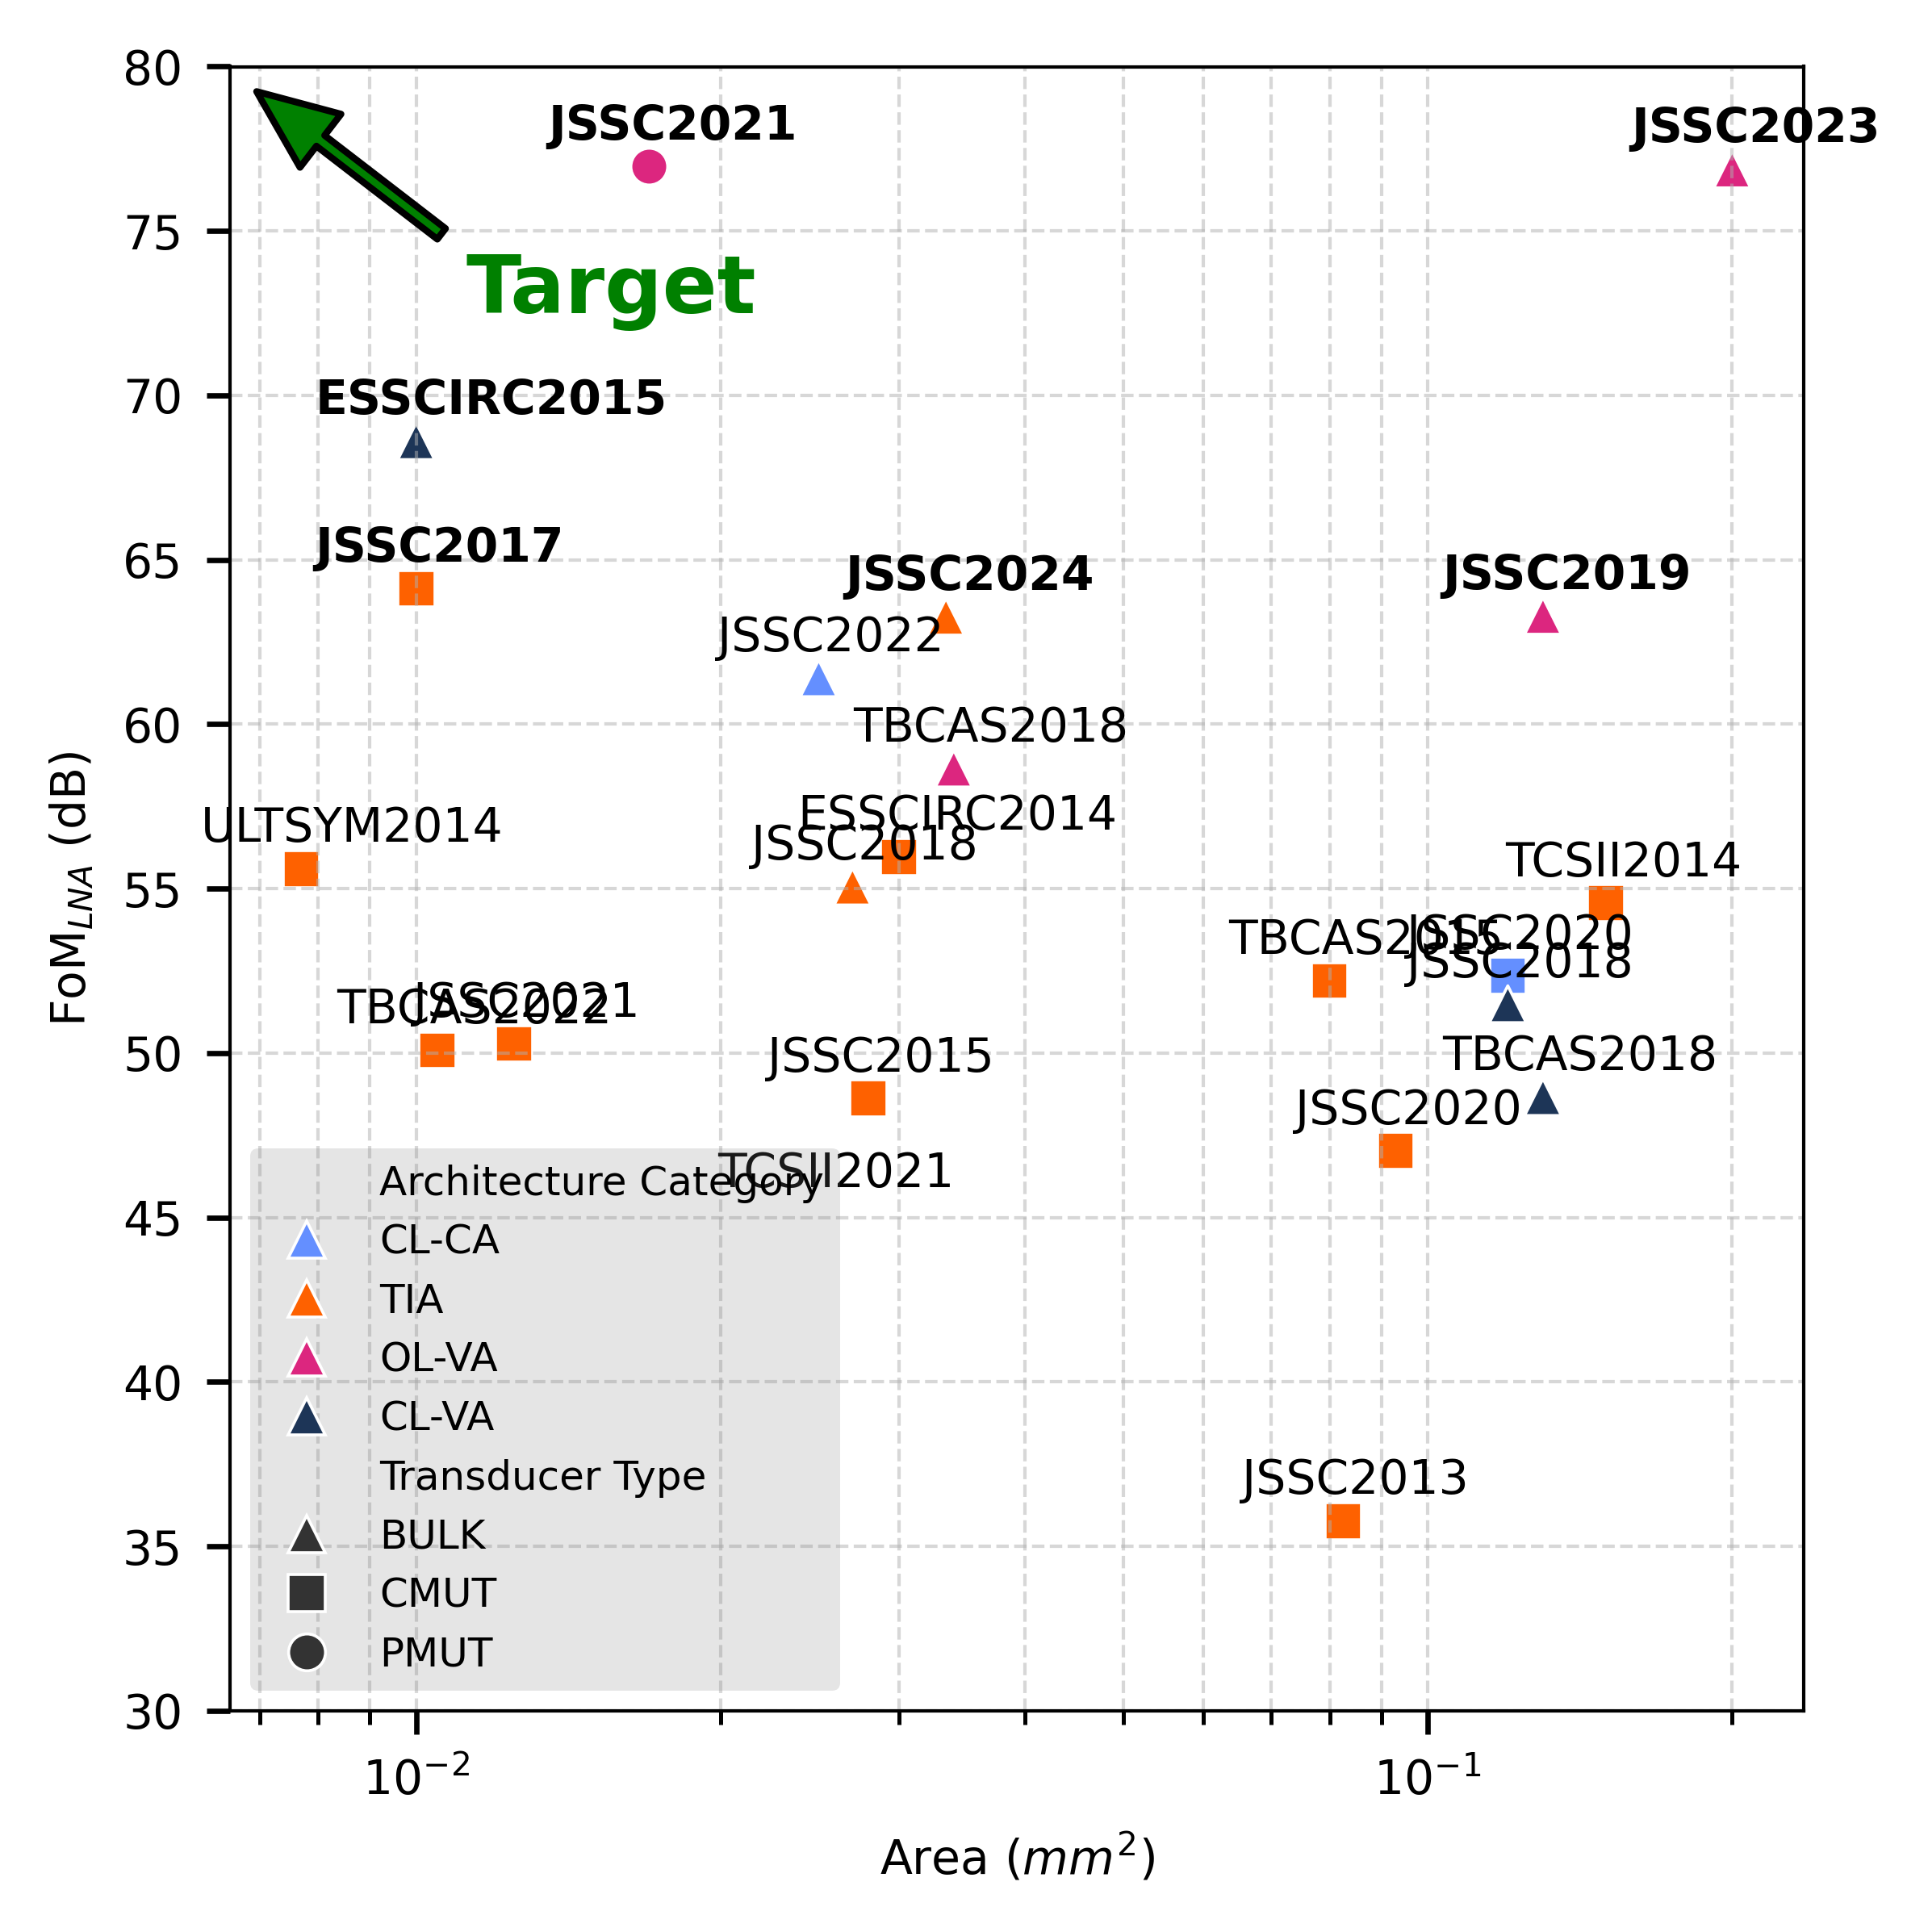

In [26]:
# plot voltage amplifiers versus TIA architectures, to observe how the choice of
# architecture affects overall performance of the main block of the AFE
fig, ax = plt.subplots(1,1, figsize=(4,4))
sns.scatterplot(
    data=lnareviewdf,
    x='Area ($mm^2$)',
    y='FoM$_{LNA}$ (dB)',
    hue='Architecture Category', # This is the column that distinguishes the classes
    style='Transducer Type',     # Controls shape/marker by class
    s=CUSTOM_DOT_SIZE,             # Sets the size of the dots
    markers=MARKER_STYLES,         # Assigns specific shapes to the classes
    palette=CUSTOM_COLORS,         # Assigns specific colors to the classes
    ax=ax,
)

step_size = 5.0
num = int(50.0 / step_size)+1
ax.set_yticks(np.linspace(30.0, 80.0, num))
ax.set_xscale('log')

FOM_THRESHOLD = 62.5

for index, row in lnareviewdf.iterrows():
    # 2. Check the threshold to determine text and weight
    display_text = row['PaperID']
    if row['FoM$_{LNA}$ (dB)'] > FOM_THRESHOLD:
        display_text += ''  # Append the custom string
        text_weight = 'bold'           # Make it bold
    else:
        text_weight = 'normal'         # Keep it regular
    ax.annotate(
        display_text,                     # The text to display
        xy=(row['Area ($mm^2$)'], row['FoM$_{LNA}$ (dB)']),   # The exact coordinates of the dot
        xytext=(-15, 6),                           # The offset: (8 points right, 0 points up/down)
        textcoords='offset points',              # Tells matplotlib to use points for the offset
        ha='left',                               # Horizontal alignment
        va='center',                             # Vertical alignment (keeps it centered with the dot)
        size='medium',
        color='black',
        weight=text_weight
    )

# 1. Add the Target Arrow pointing to the top-left
ax.annotate(
    'Target', 
    xy=(0.01, 0.99),             # The point of the arrow (5% from left, 95% from bottom)
    xytext=(0.15, 0.85),         # The location of the text
    xycoords='axes fraction',    # Use the plot's bounding box, not the data scale
    textcoords='axes fraction',  
    fontsize=12,
    fontweight='bold',
    color='green',
    arrowprops=dict(
        facecolor='green',       # Arrow color
        shrink=0.05,             # Leaves a tiny gap between the text/edge and the arrow
        width=2,                 # Thickness of the arrow tail
        headwidth=10             # Thickness of the arrow head
    )
)

ax.grid(linestyle='--', alpha=0.5, which='both')
#ax.set_yscale('log')
ax.legend(title='',frameon=True, loc='lower left',facecolor='gray', framealpha=0.2, edgecolor='none', fontsize=6)
fig.tight_layout()
fig.savefig(dir/'lna_architecture_survey.pdf', dpi=300)


In [28]:
lnareviewdf.to_csv(dir/'us_lna_survey_post_processed.csv')

In [ ]:
afesurveydf = pd.read_csv(dir/'us_multiplexing_afe_survey.csv')
afesurveydf

,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area (mm^2),Ch. Compression Ratio,Clock Speed (MHz),Noise Averaging,IRNC ($pA/\sqrt{Hz}$),IRNV ($nV/\sqrt{Hz}$),IRNA ($mPa/\sqrt{Hz}$),Center Freq. F0 (MHz),-3dB BW (MHz),DOI,Notes
0,EI-TUDelft,NurielRJSSC2025,180nm BCD-CMOS,No,2x2:µBF & 2x1:A-TDM,Yes,Yes,<2000,0.95,0.120,8,62.5,Yes,NR,NR,0.452,2.5,2.4,https://doi.org/10.1109/JSSC.2025.3534087,NR
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,3x1:µBF & 6x1:D-TDM,Yes,Yes,<=1000,1.12,0.030,18,240.0,Yes,NR,NR,0.6,4.0,9.8,https://doi.org/10.1109/JSSC.2023.3299749,NR
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,5x1:µBF & 8x1:A-TDM,Yes,Yes,<=1000,4.65,0.150,40,200.0,Yes,NR,8.6,NR,5.0,12.0,https://doi.org/10.1109/TBCAS.2022.3205024,NR
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,9x1:µBF & 4x1:D-TDM,Yes,Yes,<1000,0.91,0.026,36,30.0,Yes,NR,6.3,NR,5.0,11.9,https://doi.org/10.1109/JSSC.2018.2864295,NR
4,EI-TUDelft,PGuoJSC2024,180nm BCD-CMOS,No,2x2:µBF & 8x1:A-TDM & 4:1:D-PAM DL & SAI,Yes,Yes,<1000,1.83,0.048,32,480.0,Yes,0.7,NR,NR,9.0,14.3,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...
5,ButterflyIQ,NSanchezISSCC2021 & JRothbergPNAS2021,130nm BCD-MEMS,Yes,8x1:CES-AVRG & 4x1:D-TDM & SAI,No,Yes,>2000,0.90,0.043,32,160.0,Yes,NR,NR,0.5,5.0,10.7,https://doi.org/10.1109/ISSCC42613.2021.936580...,Originated the first Butterfly IQ handeld stat...
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,8x1:A-TDM,No,Yes,<2000,0.48,0.208,8,200.0,No,NR,NR,NR,7.0,5.0,https://doi.org/10.1109/TUFFC.2016.2557622,NR
7,ME/SCEE-GIT,MWRashidULTSYM2014,350nm CMOS,Yes,8x1:A-OFDM,No,Yes,>1000,7.25,0.154,8,320.0,Yes,16,NR,NR,7.0,20.0,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...


In [ ]:
afesurveydf['($\sqrt{F_{Cq($mm^2$)'] = afesurveydf['Active Area (mm^2)'].astype(float)
afesurveydf['FPS (Hz)'] = afesurveydf['Framerate (FPS)'].apply(lambda x: '$\leq$1000' if ('<=1000' in x or '<1000' in x) else '>1000')
afesurveydf['MUX Architecture'] = afesurveydf['Architecture'].apply(lambda x: 'µBF & TDM' if 'µBF' in x else 'O-FDM' if 'FDM' in x else 'CES' if 'CES' in x else 'A-TDM')
afesurveydf['Nr. Channels/ $mm^2$'] = afesurveydf['Area'].apply(lambda x: 'µBF & TDM' if 'µBF' in x else 'O-FDM' if 'FDM' in x else 'CES' if 'CES' in x else 'A-TDM')
afesurveydf

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-847641524.py:1: SyntaxWarning: invalid escape sequence '\s'
  afesurveydf['($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$)'] = np.sqrt(afesurveydf['Power Dissipation/Elem. (mW)']*afesurveydf['Clock Speed (MHz)']/afesurveydf['Ch. Compression Ratio'])
/tmp/ipython-input-847641524.py:3: SyntaxWarning: invalid escape sequence '\l'
  afesurveydf['FPS (Hz)'] = afesurveydf['Framerate (FPS)'].apply(lambda x: '$\leq$1000' if ('<=1000' in x or '<1000' in x) else '>1000')


,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area (mm^2),...,IRNV ($nV/\sqrt{Hz}$),IRNA ($mPa/\sqrt{Hz}$),Center Freq. F0 (MHz),-3dB BW (MHz),DOI,Notes,($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$),Area ($mm^2$),FPS (Hz),MUX Architecture
0,EI-TUDelft,NurielRJSSC2025,180nm BCD-CMOS,No,2x2:µBF & 2x1:A-TDM,Yes,Yes,<2000,0.95,0.120,...,NR,0.452,2.5,2.4,https://doi.org/10.1109/JSSC.2025.3534087,NR,2.724312,0.120,>1000,µBF & TDM
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,3x1:µBF & 6x1:D-TDM,Yes,Yes,<=1000,1.12,0.030,...,NR,0.6,4.0,9.8,https://doi.org/10.1109/JSSC.2023.3299749,NR,3.864367,0.030,$\leq$1000,µBF & TDM
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,5x1:µBF & 8x1:A-TDM,Yes,Yes,<=1000,4.65,0.150,...,8.6,NR,5.0,12.0,https://doi.org/10.1109/TBCAS.2022.3205024,NR,4.821825,0.150,$\leq$1000,µBF & TDM
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,9x1:µBF & 4x1:D-TDM,Yes,Yes,<1000,0.91,0.026,...,6.3,NR,5.0,11.9,https://doi.org/10.1109/JSSC.2018.2864295,NR,0.870823,0.026,$\leq$1000,µBF & TDM
4,EI-TUDelft,PGuoJSC2024,180nm BCD-CMOS,No,2x2:µBF & 8x1:A-TDM & 4:1:D-PAM DL & SAI,Yes,Yes,<1000,1.83,0.048,...,NR,NR,9.0,14.3,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...,5.239275,0.048,$\leq$1000,µBF & TDM
5,ButterflyIQ,NSanchezISSCC2021 & JRothbergPNAS2021,130nm BCD-MEMS,Yes,8x1:CES-AVRG & 4x1:D-TDM & SAI,No,Yes,>2000,0.90,0.043,...,NR,0.5,5.0,10.7,https://doi.org/10.1109/ISSCC42613.2021.936580...,Originated the first Butterfly IQ handeld stat...,2.121320,0.043,>1000,CES
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,8x1:A-TDM,No,Yes,<2000,0.48,0.208,...,NR,NR,7.0,5.0,https://doi.org/10.1109/TUFFC.2016.2557622,NR,3.464102,0.208,>1000,A-TDM
7,ME/SCEE-GIT,MWRashidULTSYM2014,350nm CMOS,Yes,8x1:A-OFDM,No,Yes,>1000,7.25,0.154,...,NR,NR,7.0,20.0,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...,17.029386,0.154,>1000,O-FDM


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4104059800.py:5: SyntaxWarning: invalid escape sequence '\s'
  y='($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$)',
/tmp/ipython-input-4104059800.py:2: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.scatterplot(


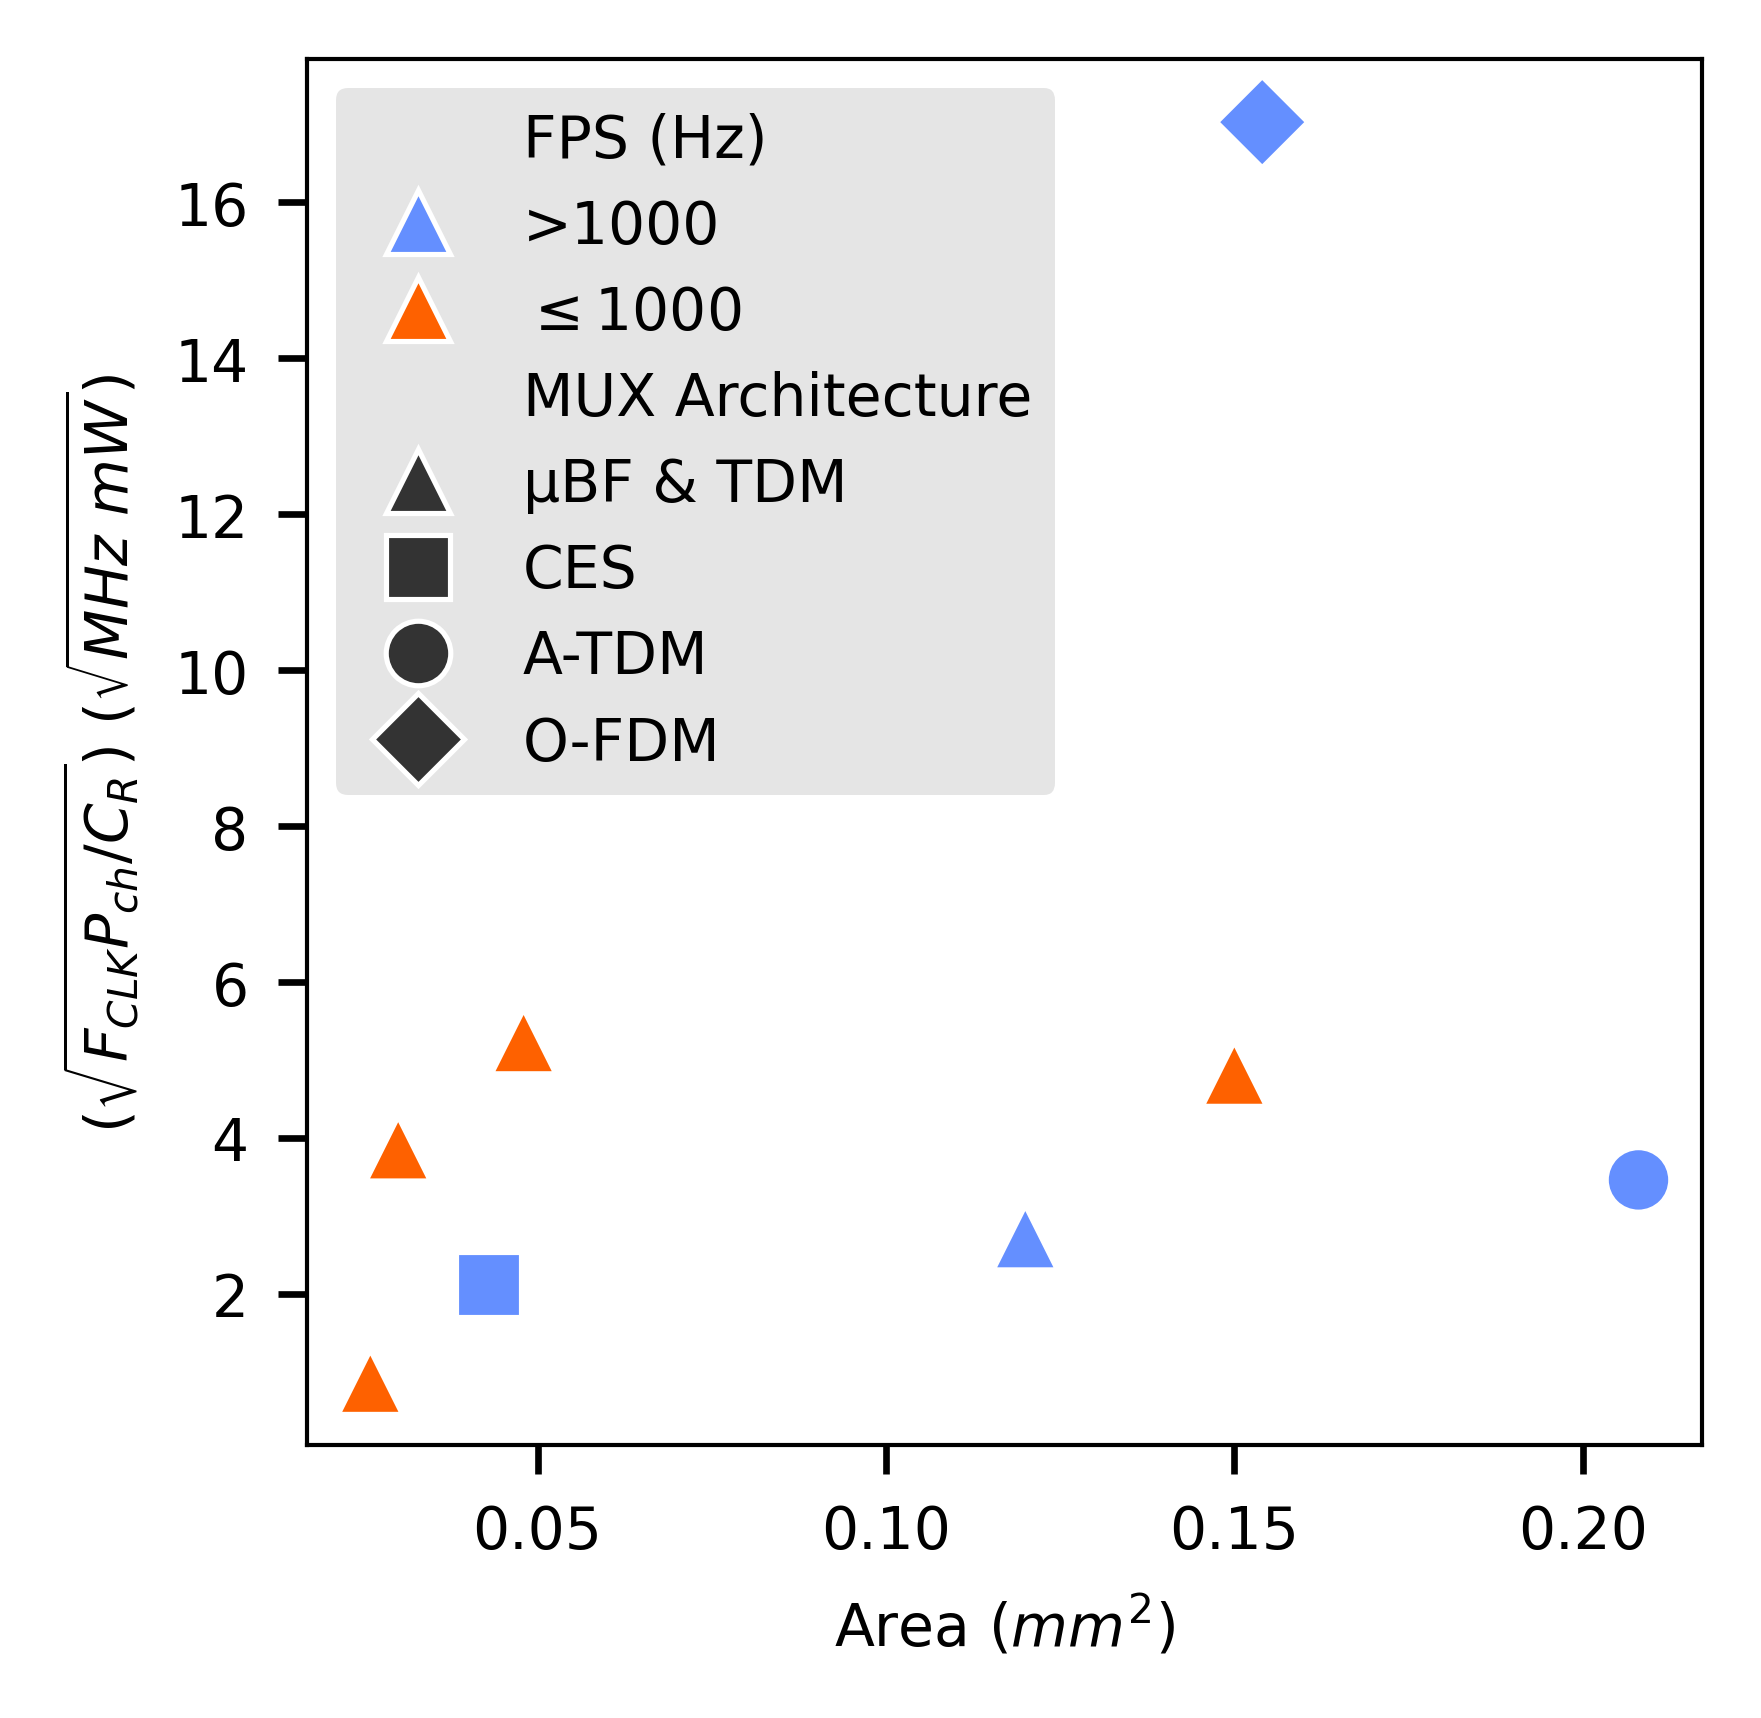

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3,3))
sns.scatterplot(
    data=afesurveydf,
    x='Area ($mm^2$)',
    y='($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$)',
    hue='FPS (Hz)', # This is the column that distinguishes the classes
    style='MUX Architecture',     # Controls shape/marker by class
    s=CUSTOM_DOT_SIZE,             # Sets the size of the dots
    markers=MARKER_STYLES,         # Assigns specific shapes to the classes
    palette=CUSTOM_COLORS,         # Assigns specific colors to the classes
    ax=ax,
)
#ax.set_xscale('log')
ax.legend(frameon=True, loc='upper left',facecolor='gray', framealpha=0.2, edgecolor='none')
#ax.set_yscale('log')
fig.savefig(dir+'afe_cmux_architecture_survey.pdf', dpi=300)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1989737054.py:5: SyntaxWarning: invalid escape sequence '\s'
  y='($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$)',
/tmp/ipython-input-1989737054.py:2: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.scatterplot(
/tmp/ipython-input-1989737054.py:2: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  sns.scatterplot(


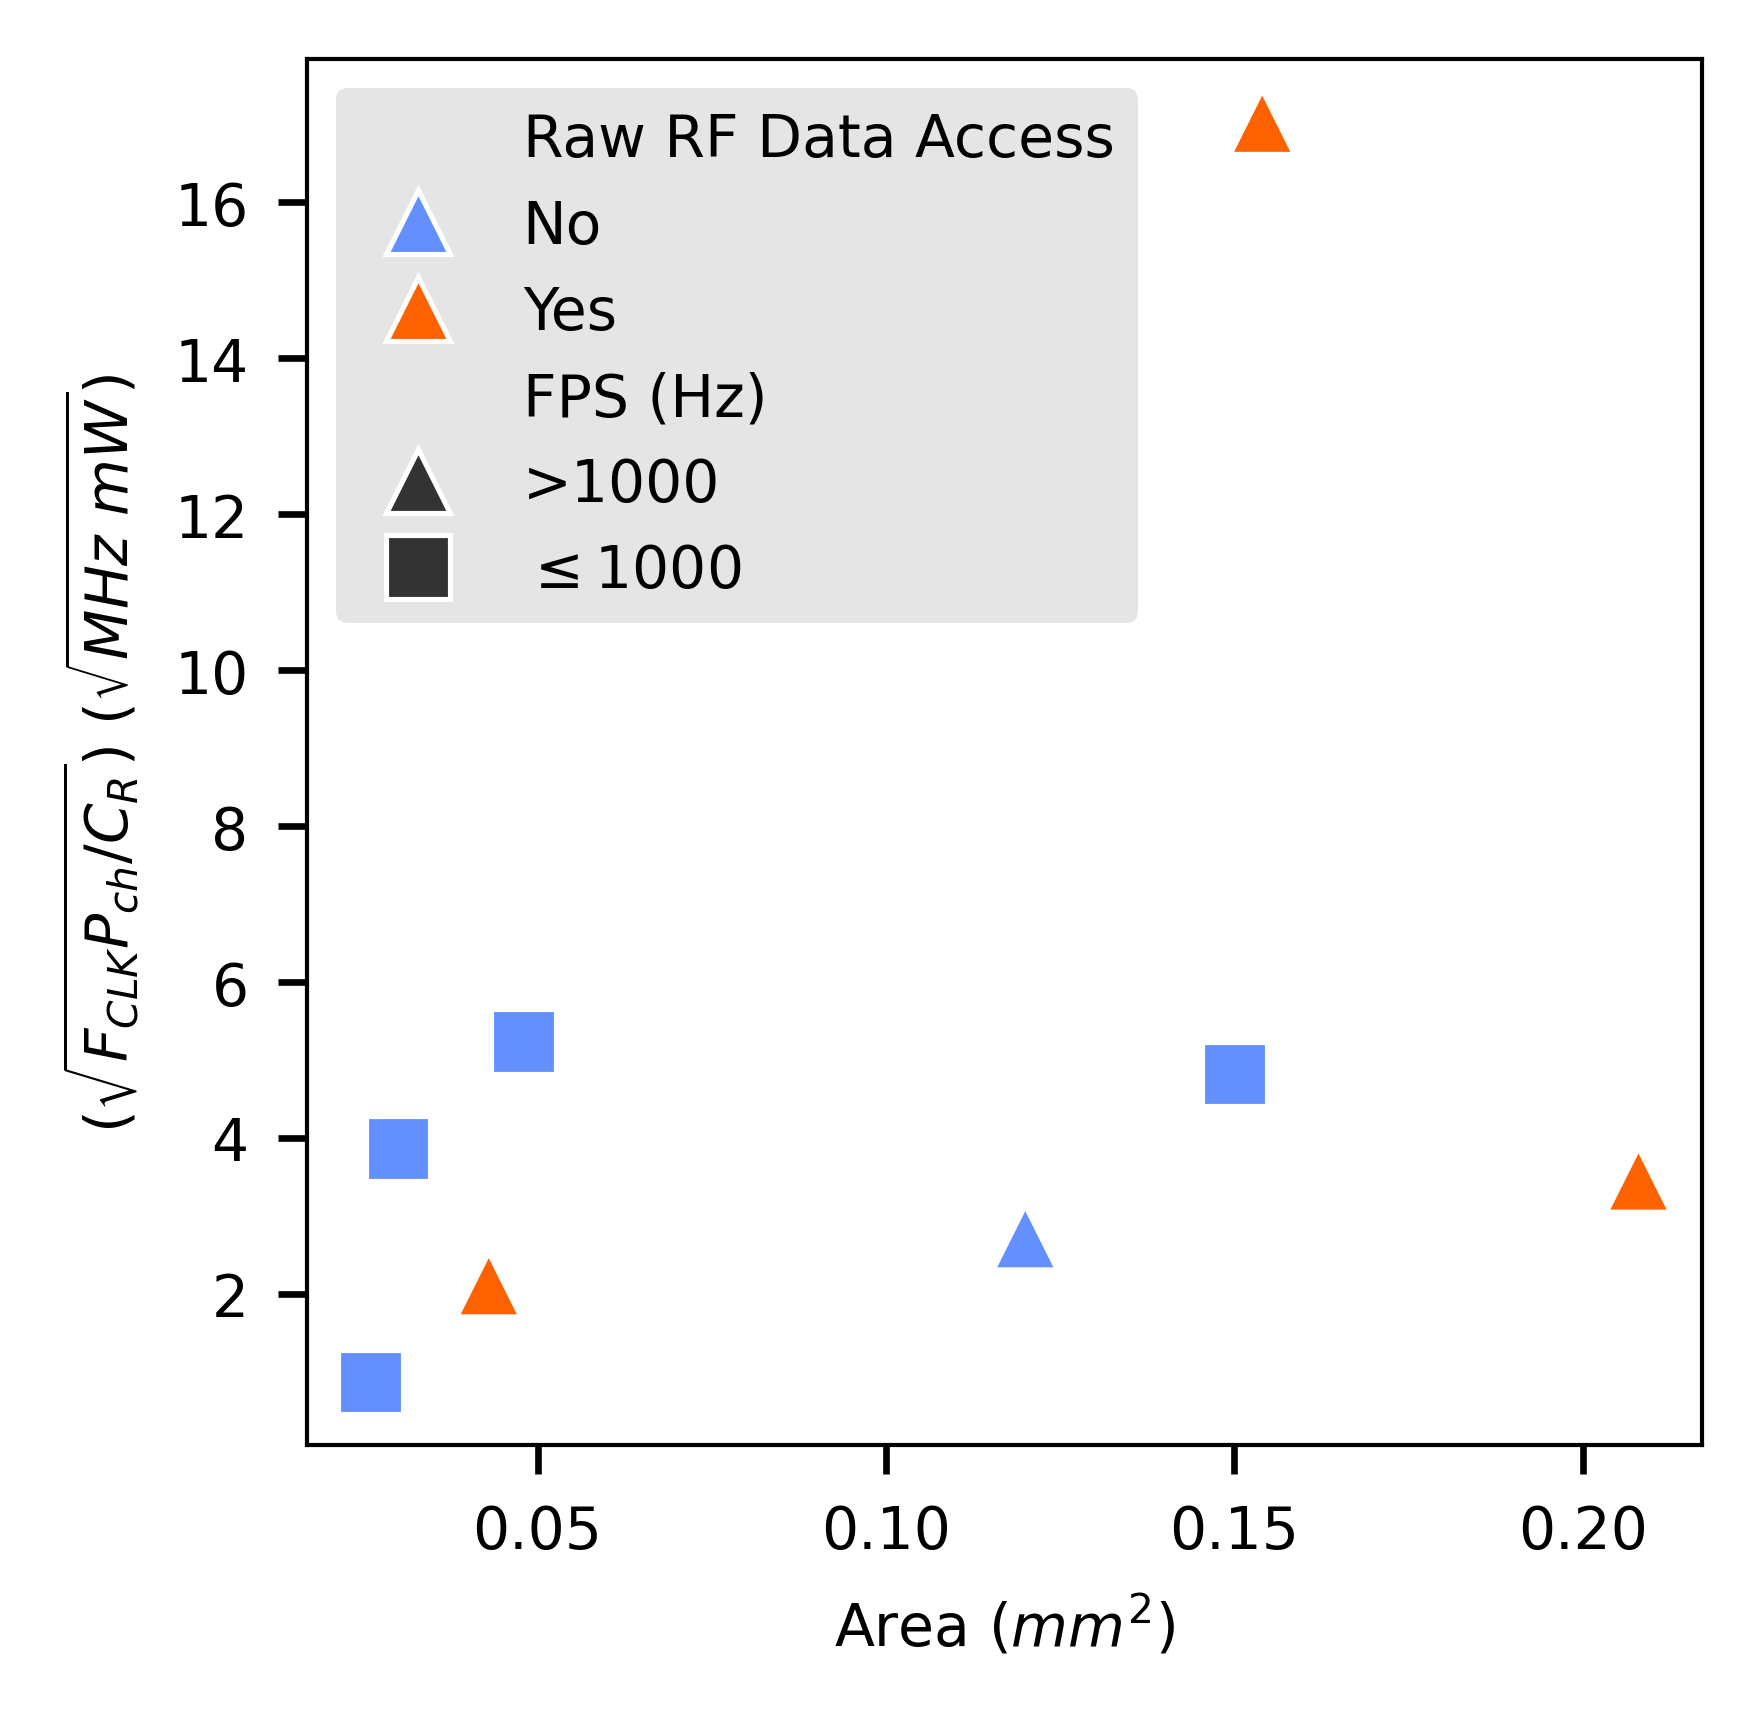

In [ ]:
efig, ax = plt.subplots(1,1, figsize=(3,3))
sns.scatterplot(
    data=afesurveydf,
    x='Area ($mm^2$)',
    y='($\sqrt{F_{CLK} P_{ch}/C_{R}}$) ($\sqrt{MHz \ mW}$)',
    hue='Raw RF Data Access', # This is the column that distinguishes the classes
    style='FPS (Hz)',     # Controls shape/marker by class
    s=CUSTOM_DOT_SIZE,             # Sets the size of the dots
    markers=MARKER_STYLES,         # Assigns specific shapes to the classes
    palette=CUSTOM_COLORS,         # Assigns specific colors to the classes
    ax=ax,
)
#ax.set_xscale('log')
ax.legend(frameon=True, loc='upper left',facecolor='gray', framealpha=0.2, edgecolor='none')
#ax.set_yscale('log')
fig.savefig(dir+'afe_cmux_architecture_survey_vs_raw_rf_data_access.pdf', dpi=300)